In [15]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import normalize
from collections import defaultdict

H5_PATH = "../embeddings/cct_dinov2l_embeddings_v2.h5"
N_BLOCKS = 10

In [16]:
import pandas as pd
import numpy as np
import h5py

with h5py.File(H5_PATH, "r") as hf:
    # 1. Load data
    raw_embeddings = hf["embeddings"][:]
    raw_species    = np.array([s.decode() for s in hf["species"][:]])
    raw_strings    = [t.decode() for t in hf["date_captured"][:]]
    raw_locations  = hf["location"][:]          # ← missing line

    # 2. Convert and Create Mask
    temp_times = pd.to_datetime(raw_strings, errors='coerce')
    mask = temp_times.notna()

    # 3. Apply Mask & Normalize
    embeddings = normalize(raw_embeddings[mask], norm="l2")
    species    = raw_species[mask]
    timestamps = temp_times[mask]
    locations  = raw_locations[mask]            # ← missing line

print(f"Loaded {len(embeddings):,} embeddings after cleaning.")
print(f"Dropped {len(mask) - mask.sum()} rows with invalid timestamps.")

Loaded 107,149 embeddings after cleaning.
Dropped 1 rows with invalid timestamps.


In [17]:
# 1. Sort everything chronologically
sort_idx = np.argsort(timestamps)

embeddings = embeddings[sort_idx]
species = species[sort_idx]

# Fix: DatetimeIndex can be indexed directly with the sort_idx array
timestamps = timestamps[sort_idx] 

# 2. Extract Date-only for the "Clever Split" 
# Use .date instead of .dt.date because 'timestamps' is likely a DatetimeIndex
dates_arr = np.array([d.date() for d in timestamps])

print(f"Data sorted. Range: {timestamps.min()} to {timestamps.max()}")
print(f"Total samples after sorting: {len(embeddings):,}")

Data sorted. Range: 2010-05-25 20:32:56 to 2015-06-03 12:07:41
Total samples after sorting: 107,149


In [18]:
def make_date_aware_blocks(dates_arr, n_blocks):
    """
    Partition indices into `n_blocks` roughly equal temporal blocks such that
    no calendar date is split across two blocks.

    Strategy:
      1. Find all unique dates in sorted order.
      2. Assign each date to a target block (0..n_blocks-1) based on cumulative
         sample count, advancing to the next block only at date boundaries.
      3. Return a list of index arrays, one per block.
    """
    N = len(dates_arr)
    target_block_size = N / n_blocks

    # Build a lookup: date → list of row indices (already sorted by time)
    date_to_indices = defaultdict(list)
    for idx, d in enumerate(dates_arr):
        date_to_indices[d].append(idx)

    unique_dates = sorted(date_to_indices.keys())

    blocks   = [[] for _ in range(n_blocks)]
    cur_block = 0
    cumulative = 0

    for d in unique_dates:
        idxs = date_to_indices[d]
        blocks[cur_block].extend(idxs)
        cumulative += len(idxs)
        # Advance to next block when we pass the target boundary,
        # but never exceed n_blocks - 1.
        if cur_block < n_blocks - 1 and cumulative >= (cur_block + 1) * target_block_size:
            cur_block += 1

    return [np.array(b) for b in blocks if len(b) > 0]


blocks = make_date_aware_blocks(dates_arr, N_BLOCKS)

print(f"Created {len(blocks)} temporal blocks (target: {N_BLOCKS})")
print(f"{'Block':>6}  {'Size':>7}  {'Date range'}")
print("-" * 55)
for i, b in enumerate(blocks):
    d_min = dates_arr[b].min()
    d_max = dates_arr[b].max()
    print(f"  {i+1:>4}  {len(b):>7,}  {d_min}  →  {d_max}")

Created 10 temporal blocks (target: 10)
 Block     Size  Date range
-------------------------------------------------------
     1   10,798  2010-05-25  →  2011-06-14
     2   10,685  2011-06-15  →  2011-09-14
     3   10,767  2011-09-15  →  2012-01-03
     4   10,659  2012-01-04  →  2012-03-28
     5   10,710  2012-03-29  →  2012-05-25
     6   10,755  2012-05-26  →  2013-10-23
     7   10,734  2013-10-24  →  2014-01-24
     8   10,769  2014-01-25  →  2014-05-07
     9   10,571  2014-05-08  →  2014-09-07
    10   10,701  2014-09-08  →  2015-06-03


In [19]:
import copy
import numpy as np
import matplotlib.pyplot as plt

In [20]:
class AdaptiveNCMClassifier:
    def __init__(self):
        self.prototypes = {}
        self.counts = {}

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _compute_dists(self, query_emb):
        species_list = list(self.prototypes.keys())
        query_norm = self._normalized(query_emb)
        protos_norm = np.array([
            self._normalized(self.prototypes[cls]) for cls in species_list
        ])

        dots = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
        return species_list, dists

    def _unknown_score(self, dists, method="energy", T=0.1):
        if method == "energy":
            scaled = -dists / T
            max_s = np.max(scaled)
            return float(-(T * (max_s + np.log(np.sum(np.exp(scaled - max_s))))))

        if method == "ratio":
            sd = np.sort(dists)
            return float(sd[0] / (sd[1] + 1e-9)) if len(sd) >= 2 else 0.0

        raise ValueError(f"Unknown method: {method!r}")

    def fit(self, g_embs, g_labels):
        unique_classes = np.unique(g_labels)
        for cls in unique_classes:
            cls_embs = g_embs[g_labels == cls]
            self.prototypes[cls] = np.mean(cls_embs, axis=0)
            self.counts[cls] = len(cls_embs)

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)

        if n == 0:
            self.prototypes[species] = new_emb.copy()
            self.counts[species] = 1
            return

        old_proto = self.prototypes[species]
        new_n = n + 1
        self.prototypes[species] = (old_proto * n + new_emb) / new_n
        self.counts[species] = new_n

    def predict(self, query_emb, threshold, method="energy", T=0.1):
        species_list, dists = self._compute_dists(query_emb)

        nearest_idx = int(np.argmin(dists))
        pred = species_list[nearest_idx]

        score = self._unknown_score(dists, method=method, T=T)
        is_unknown = score > threshold

        return pred, is_unknown

    @property
    def known_species(self):
        return set(self.prototypes.keys())

In [21]:
def calibrate_threshold(clf, cal_embs, cal_lbls, method, T, fpr_target):
    known = clf.known_species
    scores = []

    for emb, lbl in zip(cal_embs, cal_lbls):
        if lbl not in known:
            continue

        _, dists = clf._compute_dists(emb)
        score = clf._unknown_score(dists, method=method, T=T)
        scores.append(score)

    if not scores:
        return -np.inf

    return float(np.quantile(scores, 1 - fpr_target))

In [22]:
def evaluate_block(clf, embs, lbls, threshold, method="energy", T=0.2):
    known_at_eval = clf.known_species.copy()
    species_in_block = sorted(set(lbls))

    sp_correct = {sp: 0 for sp in species_in_block}
    sp_total = {sp: 0 for sp in species_in_block}

    classification_correct = 0
    new_species_total = 0
    correctly_flagged_new = 0

    for emb, lbl in zip(embs, lbls):
        pred, is_unknown = clf.predict(emb, threshold=threshold, method=method, T=T)

        sp_total[lbl] += 1
        if pred == lbl:
            classification_correct += 1
            sp_correct[lbl] += 1

        if lbl not in known_at_eval:
            new_species_total += 1
            if is_unknown:
                correctly_flagged_new += 1

    total = len(lbls)

    return {
        "classification_accuracy": 100 * classification_correct / total if total else float("nan"),
        "per_species_accuracy": {
            sp: (100 * sp_correct[sp] / sp_total[sp] if sp_total[sp] > 0 else float("nan"))
            for sp in species_in_block
        },
        "outlier_detection_rate": (
            correctly_flagged_new / new_species_total if new_species_total > 0 else float("nan")
        ),
        "n_correct_classifications": classification_correct,
        "n_new_species_samples": new_species_total,
        "n_detected_outliers": correctly_flagged_new,
        "total": total,
    }

def update_classifier_on_block(clf, embs, lbls):
    for emb, lbl in zip(embs, lbls):
        clf.update(emb, lbl)

In [27]:
from tqdm import tqdm
import copy
import numpy as np


def update_classifier_on_block(clf, embs, lbls, show_progress=False, desc="Updating classifier"):
    iterator = zip(embs, lbls)
    total = len(lbls)

    if show_progress:
        iterator = tqdm(iterator, total=total, desc=desc, leave=False)

    for emb, lbl in iterator:
        clf.update(emb, lbl)


def run_pipeline_with_calibration(
    start_clf,
    blocks,
    embeddings,
    species,
    baseline_row,
    initial_cal_embs,
    initial_cal_lbls,
    update_after_eval=True,
    recalibrate_after_eval=True,
    method="energy",
    T=0.1,
    fpr_target=0.05,
    calibration_memory_max=None,
    show_progress=True,
    progress_desc="Streaming blocks",
):
    clf = copy.deepcopy(start_clf)
    results = [baseline_row.copy()]

    cal_embs_hist = np.asarray(initial_cal_embs).copy()
    cal_lbls_hist = np.asarray(initial_cal_lbls).copy()

    current_threshold = calibrate_threshold(
        clf, cal_embs_hist, cal_lbls_hist, method=method, T=T, fpr_target=fpr_target
    )

    block_iter = enumerate(blocks[1:], start=2)
    if show_progress:
        block_iter = tqdm(
            block_iter,
            total=len(blocks) - 1,
            desc=progress_desc,
        )

    for blk_num, blk_idx in block_iter:
        blk_idx = np.asarray(blk_idx)
        blk_embs = embeddings[blk_idx]
        blk_lbls = species[blk_idx]

        metrics = evaluate_block(
            clf,
            blk_embs,
            blk_lbls,
            threshold=current_threshold,
            method=method,
            T=T,
        )

        results.append({
            "block": blk_num,
            **metrics,
            "n_known_species": len(clf.known_species),
            "threshold": current_threshold,
        })

        if update_after_eval:
            update_classifier_on_block(
                clf,
                blk_embs,
                blk_lbls,
                show_progress=show_progress,
                desc=f"Updating after block {blk_num}",
            )

        if recalibrate_after_eval:
            cal_embs_hist = np.concatenate([cal_embs_hist, blk_embs], axis=0)
            cal_lbls_hist = np.concatenate([cal_lbls_hist, blk_lbls], axis=0)

            if calibration_memory_max is not None and len(cal_lbls_hist) > calibration_memory_max:
                cal_embs_hist = cal_embs_hist[-calibration_memory_max:]
                cal_lbls_hist = cal_lbls_hist[-calibration_memory_max:]

            current_threshold = calibrate_threshold(
                clf, cal_embs_hist, cal_lbls_hist, method=method, T=T, fpr_target=fpr_target
            )

    return results


def print_results(results, title=None):
    if title is not None:
        print(f"\n{title}")

    for row in results:
        print(f"\n{'='*50}")
        print(f"Block {row['block']}")
        print(f"{'='*50}")
        print(f"  Classification Accuracy: {row['classification_accuracy']:.1f}%")
        print(
            f"  Outlier Detection Rate:  {row['outlier_detection_rate']:.1%}"
            if not np.isnan(row["outlier_detection_rate"])
            else "  Outlier Detection Rate:  N/A"
        )
        print(f"  Known Species:           {row['n_known_species']}")
        print(f"  Total Samples:           {row['total']}")
        print(f"  Correct Classifications: {row['n_correct_classifications']}")
        print(f"  New Species Samples:     {row['n_new_species_samples']}")
        print(f"  Detected Outliers:       {row['n_detected_outliers']}")
        if "threshold" in row and not np.isnan(row["threshold"]):
            print(f"  Threshold:               {row['threshold']:.6f}")


# ------------------------------------------------------------
# Main workflow
# ------------------------------------------------------------

# Settings
INIT_CAL_RATIO = 0.5
INIT_TRAIN_RATIO = 0.6
OOD_METHOD = "energy"          # "energy" or "ratio"
TEMPERATURE = 0.1              # only used for energy
FPR_TARGET = 0.1
CALIBRATION_MEMORY_MAX = 2000
SHOW_PROGRESS = True

embeddings = np.asarray(embeddings)
species = np.asarray(species)

print("Initializing classifier...")
clf_block1 = AdaptiveNCMClassifier()

b0_idx = np.asarray(blocks[0])
n_b0 = len(b0_idx)

n_fit = max(1, int(INIT_TRAIN_RATIO * n_b0))
remaining = n_b0 - n_fit
n_cal = max(1, int(INIT_CAL_RATIO * remaining)) if remaining >= 2 else 0

if n_fit + n_cal >= n_b0:
    raise ValueError("Block 1 split leaves no hold-out evaluation samples. Reduce INIT_TRAIN_RATIO or INIT_CAL_RATIO.")

fit_idx = b0_idx[:n_fit]
cal_idx = b0_idx[n_fit:n_fit + n_cal]
b0_eval_idx = b0_idx[n_fit + n_cal:]

print("Fitting on Block 1 train split...")
clf_block1.fit(embeddings[fit_idx], species[fit_idx])

print("Calibrating initial threshold...")
baseline_threshold = calibrate_threshold(
    clf_block1,
    embeddings[cal_idx],
    species[cal_idx],
    method=OOD_METHOD,
    T=TEMPERATURE,
    fpr_target=FPR_TARGET,
)

print("Evaluating Block 1 hold-out split...")
baseline_metrics = evaluate_block(
    clf_block1,
    embeddings[b0_eval_idx],
    species[b0_eval_idx],
    threshold=baseline_threshold,
    method=OOD_METHOD,
    T=TEMPERATURE,
)

baseline_row = {
    "block": 1,
    **baseline_metrics,
    "n_known_species": len(clf_block1.known_species),
    "threshold": baseline_threshold,
}

print(f"Block 1 total samples              : {n_b0:,}")
print(f"Block 1 fit samples                : {len(fit_idx):,}")
print(f"Block 1 calibration samples        : {len(cal_idx):,}")
print(f"Block 1 hold-out eval samples      : {len(b0_eval_idx):,}")
print(f"Initial known species              : {len(clf_block1.known_species)}")
print(f"Initial threshold                  : {baseline_threshold:.6f}")
print(f"Block 1 classification accuracy    : {baseline_row['classification_accuracy']:.3f}")
print(
    f"Block 1 outlier detection rate     : {baseline_row['outlier_detection_rate']:.3f}"
    if not np.isnan(baseline_row["outlier_detection_rate"])
    else "Block 1 outlier detection rate     : N/A"
)

print("Updating classifier with Block 1 evaluation samples...")
update_classifier_on_block(
    clf_block1,
    embeddings[b0_eval_idx],
    species[b0_eval_idx],
    show_progress=SHOW_PROGRESS,
    desc="Updating after Block 1",
)

cal_embs_hist = embeddings[cal_idx]
cal_lbls_hist = species[cal_idx]

if len(b0_eval_idx) > 0:
    cal_embs_hist = np.concatenate([cal_embs_hist, embeddings[b0_eval_idx]], axis=0)
    cal_lbls_hist = np.concatenate([cal_lbls_hist, species[b0_eval_idx]], axis=0)

clf_start = copy.deepcopy(clf_block1)
print(f"Known species after Block 1        : {len(clf_start.known_species)}")

print("Running adaptive pipeline...")
adaptive_results = run_pipeline_with_calibration(
    start_clf=clf_start,
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    baseline_row=baseline_row,
    initial_cal_embs=cal_embs_hist,
    initial_cal_lbls=cal_lbls_hist,
    update_after_eval=True,
    recalibrate_after_eval=True,
    method=OOD_METHOD,
    T=TEMPERATURE,
    fpr_target=FPR_TARGET,
    calibration_memory_max=CALIBRATION_MEMORY_MAX,
    show_progress=SHOW_PROGRESS,
    progress_desc="Adaptive blocks",
)

print("Running static pipeline...")
static_results = run_pipeline_with_calibration(
    start_clf=clf_start,
    blocks=blocks,
    embeddings=embeddings,
    species=species,
    baseline_row=baseline_row,
    initial_cal_embs=cal_embs_hist,
    initial_cal_lbls=cal_lbls_hist,
    update_after_eval=False,
    recalibrate_after_eval=False,
    method=OOD_METHOD,
    T=TEMPERATURE,
    fpr_target=FPR_TARGET,
    calibration_memory_max=CALIBRATION_MEMORY_MAX,
    show_progress=SHOW_PROGRESS,
    progress_desc="Static blocks",
)

# Optional
# print_results(adaptive_results, title="ADAPTIVE")
# print_results(static_results, title="STATIC")

Initializing classifier...
Fitting on Block 1 train split...
Calibrating initial threshold...
Evaluating Block 1 hold-out split...
Block 1 total samples              : 10,798
Block 1 fit samples                : 6,478
Block 1 calibration samples        : 2,160
Block 1 hold-out eval samples      : 2,160
Initial known species              : 15
Initial threshold                  : 0.940532
Block 1 classification accuracy    : 80.370
Block 1 outlier detection rate     : N/A
Updating classifier with Block 1 evaluation samples...


Known species after Block 1        : 15
Running adaptive pipeline...


Adaptive blocks: 100%|██████████| 9/9 [00:19<00:00,  2.17s/it]    


Running static pipeline...


Static blocks: 100%|██████████| 9/9 [00:14<00:00,  1.59s/it]


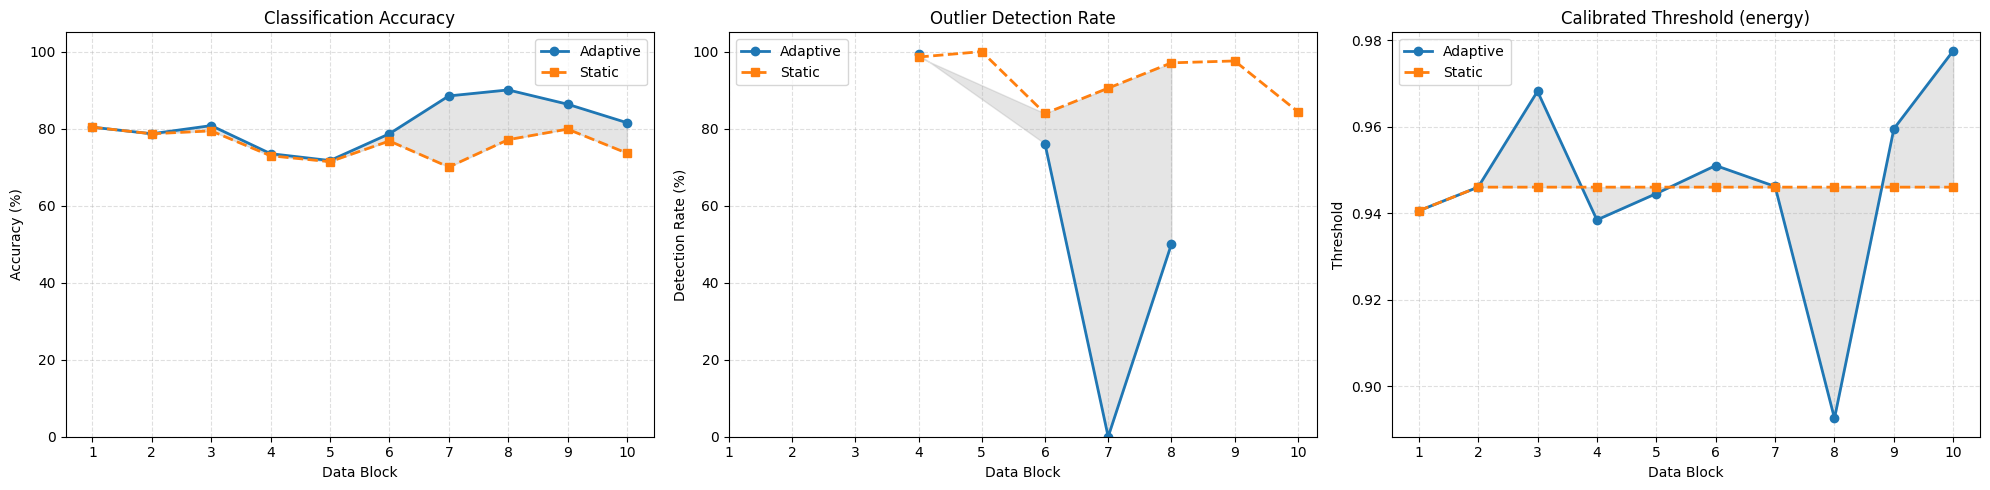

In [28]:
import numpy as np
import matplotlib.pyplot as plt

adaptive_blocks = [r["block"] for r in adaptive_results]
adaptive_cls = [r["classification_accuracy"] for r in adaptive_results]
adaptive_ood = [
    r["outlier_detection_rate"] * 100 if not np.isnan(r["outlier_detection_rate"]) else np.nan
    for r in adaptive_results
]
adaptive_thr = [
    r["threshold"] if ("threshold" in r and not np.isnan(r["threshold"])) else np.nan
    for r in adaptive_results
]

static_blocks = [r["block"] for r in static_results]
static_cls = [r["classification_accuracy"] for r in static_results]
static_ood = [
    r["outlier_detection_rate"] * 100 if not np.isnan(r["outlier_detection_rate"]) else np.nan
    for r in static_results
]
static_thr = [
    r["threshold"] if ("threshold" in r and not np.isnan(r["threshold"])) else np.nan
    for r in static_results
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ------------------------------------------------------------
# 1. Classification accuracy
# ------------------------------------------------------------
axes[0].plot(
    adaptive_blocks, adaptive_cls,
    marker="o", linewidth=2, label="Adaptive"
)
axes[0].plot(
    static_blocks, static_cls,
    marker="s", linewidth=2, linestyle="--", label="Static"
)

common_len = min(len(adaptive_blocks), len(static_blocks))
x_common = np.array(adaptive_blocks[:common_len])
y_adaptive_cls = np.array(adaptive_cls[:common_len], dtype=float)
y_static_cls = np.array(static_cls[:common_len], dtype=float)

axes[0].fill_between(
    x_common,
    y_adaptive_cls,
    y_static_cls,
    color="gray",
    alpha=0.2
)

axes[0].set_title("Classification Accuracy")
axes[0].set_xlabel("Data Block")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 105)
axes[0].set_xticks(adaptive_blocks)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

# ------------------------------------------------------------
# 2. Outlier detection rate
# ------------------------------------------------------------
axes[1].plot(
    adaptive_blocks, adaptive_ood,
    marker="o", linewidth=2, label="Adaptive"
)
axes[1].plot(
    static_blocks, static_ood,
    marker="s", linewidth=2, linestyle="--", label="Static"
)

y_adaptive_ood = np.array(adaptive_ood[:common_len], dtype=float)
y_static_ood = np.array(static_ood[:common_len], dtype=float)
valid_ood = ~(np.isnan(y_adaptive_ood) | np.isnan(y_static_ood))

if np.any(valid_ood):
    axes[1].fill_between(
        x_common[valid_ood],
        y_adaptive_ood[valid_ood],
        y_static_ood[valid_ood],
        color="gray",
        alpha=0.2
    )

axes[1].set_title("Outlier Detection Rate")
axes[1].set_xlabel("Data Block")
axes[1].set_ylabel("Detection Rate (%)")
axes[1].set_ylim(0, 105)
axes[1].set_xticks(adaptive_blocks)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

# ------------------------------------------------------------
# 3. Threshold over blocks
# ------------------------------------------------------------
axes[2].plot(
    adaptive_blocks, adaptive_thr,
    marker="o", linewidth=2, label="Adaptive"
)
axes[2].plot(
    static_blocks, static_thr,
    marker="s", linewidth=2, linestyle="--", label="Static"
)

y_adaptive_thr = np.array(adaptive_thr[:common_len], dtype=float)
y_static_thr = np.array(static_thr[:common_len], dtype=float)
valid_thr = ~(np.isnan(y_adaptive_thr) | np.isnan(y_static_thr))

if np.any(valid_thr):
    axes[2].fill_between(
        x_common[valid_thr],
        y_adaptive_thr[valid_thr],
        y_static_thr[valid_thr],
        color="gray",
        alpha=0.2
    )

axes[2].set_title(f"Calibrated Threshold ({OOD_METHOD})")
axes[2].set_xlabel("Data Block")
axes[2].set_ylabel("Threshold")
axes[2].set_xticks(adaptive_blocks)
axes[2].grid(True, linestyle="--", alpha=0.4)
axes[2].legend()

plt.tight_layout()
#plt.savefig("plots/streaming_open_set_results.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [29]:
import pandas as pd
import numpy as np
import h5py

with h5py.File(H5_PATH, "r") as hf:
    # 1. Load data
    raw_embeddings = hf["embeddings"][:]
    raw_species    = np.array([s.decode() for s in hf["species"][:]])
    raw_strings    = [t.decode() for t in hf["date_captured"][:]]
    raw_locations  = hf["location"][:]          # ← missing line

    # 2. Convert and Create Mask
    temp_times = pd.to_datetime(raw_strings, errors='coerce')
    mask = temp_times.notna()

    # 3. Apply Mask & Normalize
    embeddings = normalize(raw_embeddings[mask], norm="l2")
    species    = raw_species[mask]
    timestamps = temp_times[mask]
    locations  = raw_locations[mask]            # ← missing line

print(f"Loaded {len(embeddings):,} embeddings after cleaning.")
print(f"Dropped {len(mask) - mask.sum()} rows with invalid timestamps.")

Loaded 107,149 embeddings after cleaning.
Dropped 1 rows with invalid timestamps.


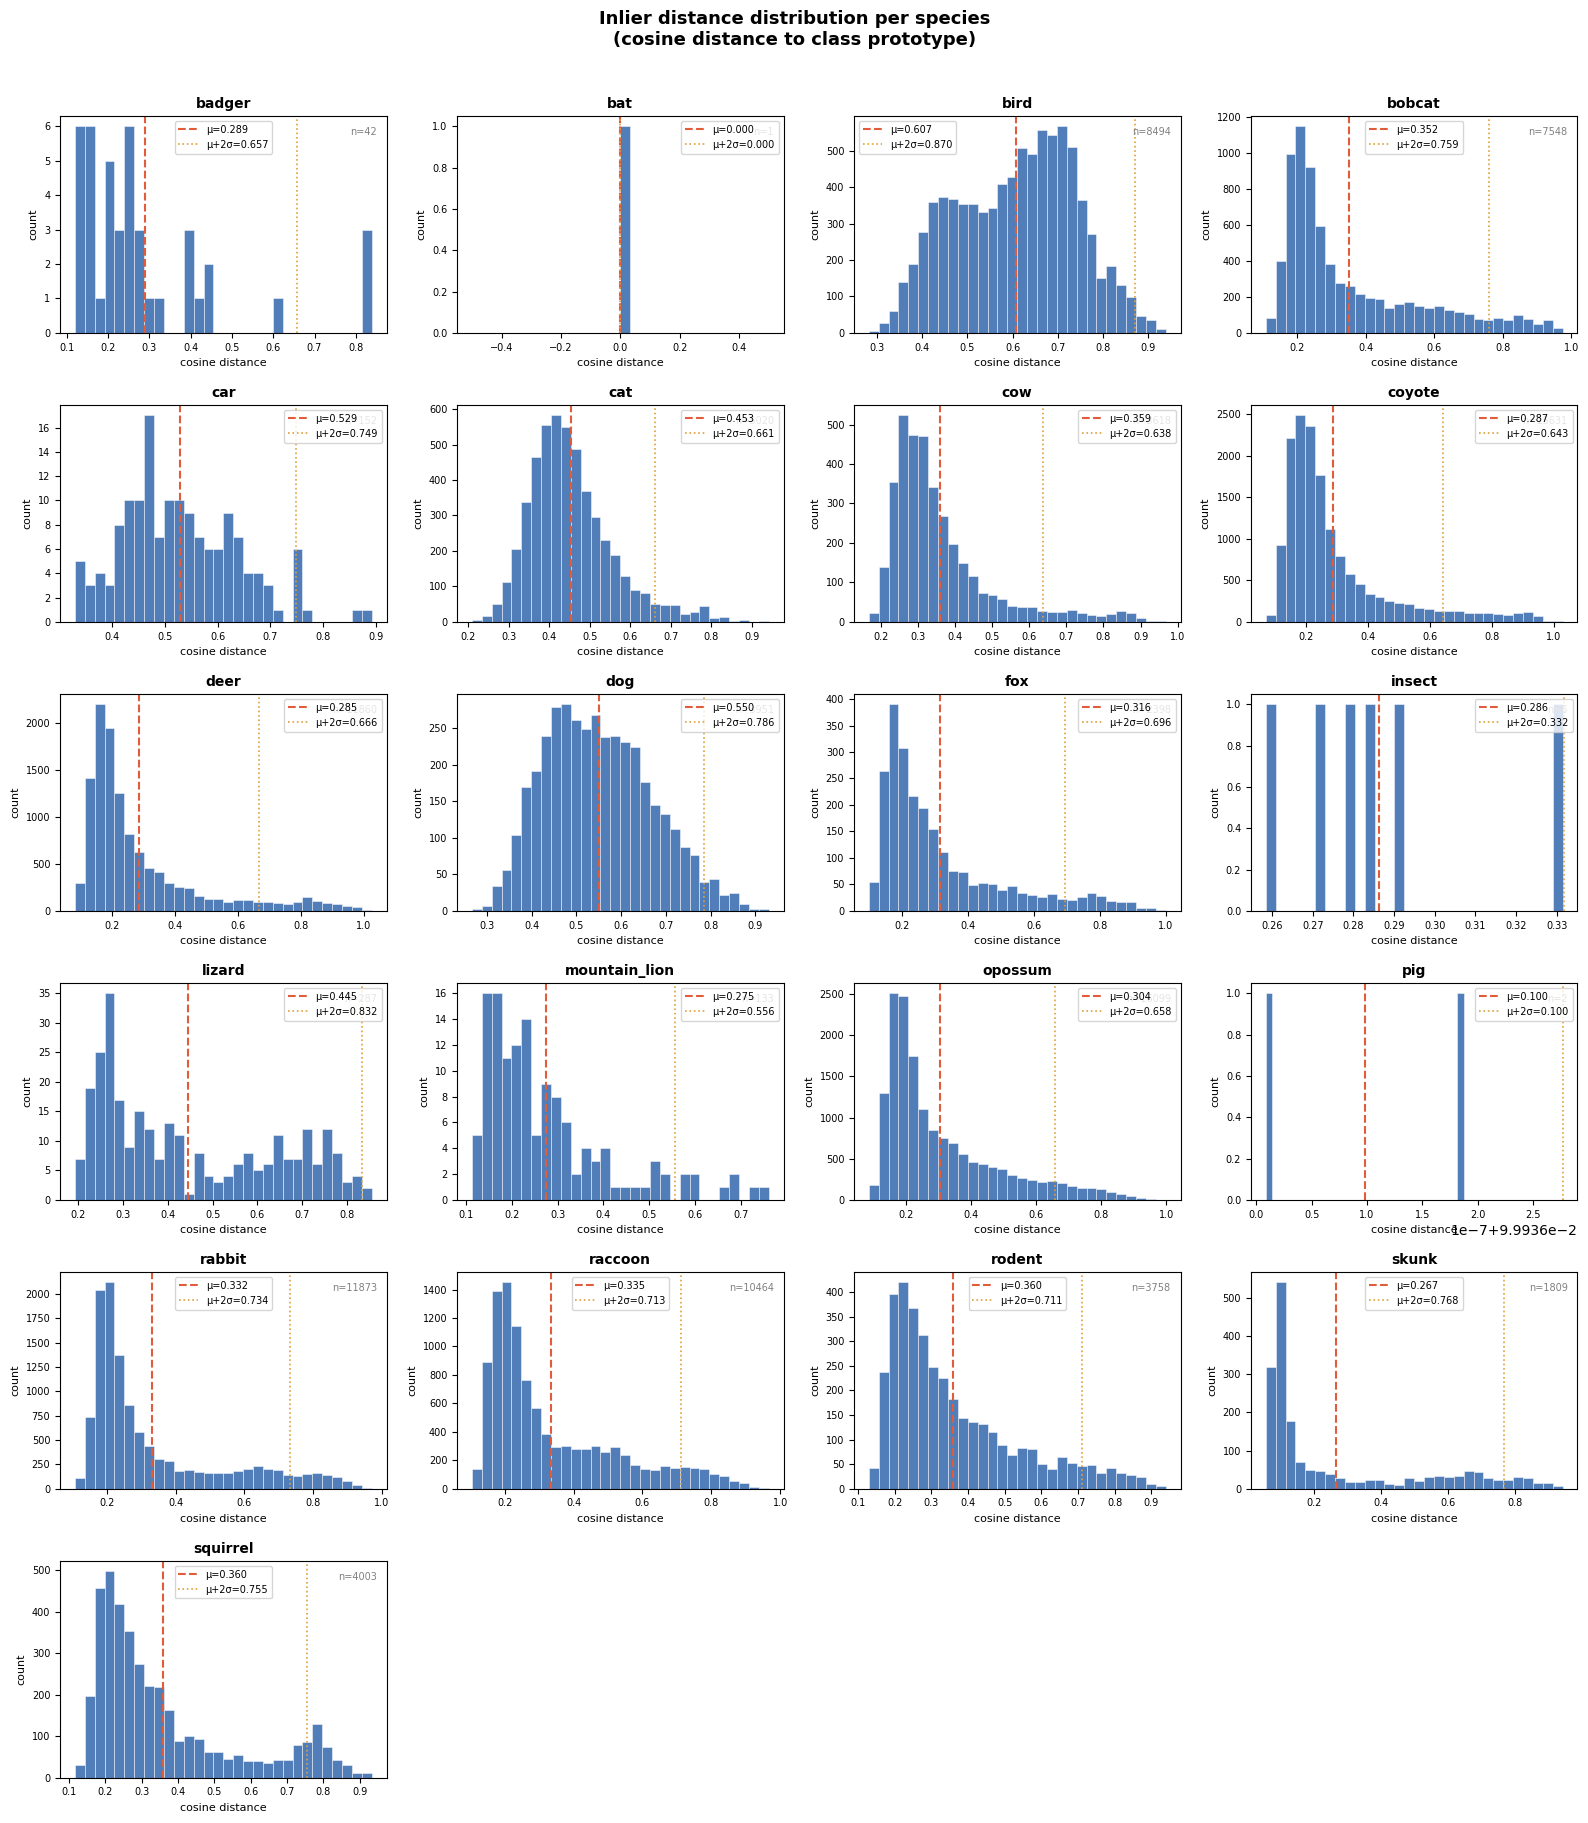

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import normalize
from collections import defaultdict

# ── 1. Build per-class prototypes ──────────────────────────────────────────────
unique_species = np.unique(species)
prototypes = {}
for sp in unique_species:
    mask_sp = species == sp
    proto = embeddings[mask_sp].mean(axis=0)
    prototypes[sp] = proto / np.linalg.norm(proto)   # re-normalize

# ── 2. Compute per-sample distances to own-class prototype ────────────────────
# cosine distance = 1 - cosine_similarity (embeddings already L2-normalized)
inlier_distances = defaultdict(list)

for sp in unique_species:
    mask_sp = species == sp
    embs = embeddings[mask_sp]                        # (N, D)
    proto = prototypes[sp]                            # (D,)
    cos_sim = embs @ proto                            # (N,) dot product = cosine sim for unit vecs
    cos_dist = 1.0 - cos_sim
    inlier_distances[sp] = cos_dist.tolist()

# ── 3. Plot ────────────────────────────────────────────────────────────────────
n_species = len(unique_species)
ncols = 4
nrows = int(np.ceil(n_species / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, sp in enumerate(sorted(unique_species)):
    dists = np.array(inlier_distances[sp])
    ax = axes[i]
    ax.hist(dists, bins=30, color="#3266ad", edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(np.mean(dists),  color="#e05c3a", linewidth=1.5, linestyle="--", label=f"μ={np.mean(dists):.3f}")
    ax.axvline(np.mean(dists) + 2*np.std(dists), color="#e0a03a", linewidth=1.2,
               linestyle=":", label=f"μ+2σ={np.mean(dists)+2*np.std(dists):.3f}")
    ax.set_title(sp, fontsize=10, fontweight="bold")
    ax.set_xlabel("cosine distance", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    n = len(dists)
    ax.text(0.97, 0.95, f"n={n}", transform=ax.transAxes,
            ha="right", va="top", fontsize=7, color="gray")

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Inlier distance distribution per species\n(cosine distance to class prototype)", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("inlier_distances_per_species.png", dpi=150, bbox_inches="tight")
plt.show()

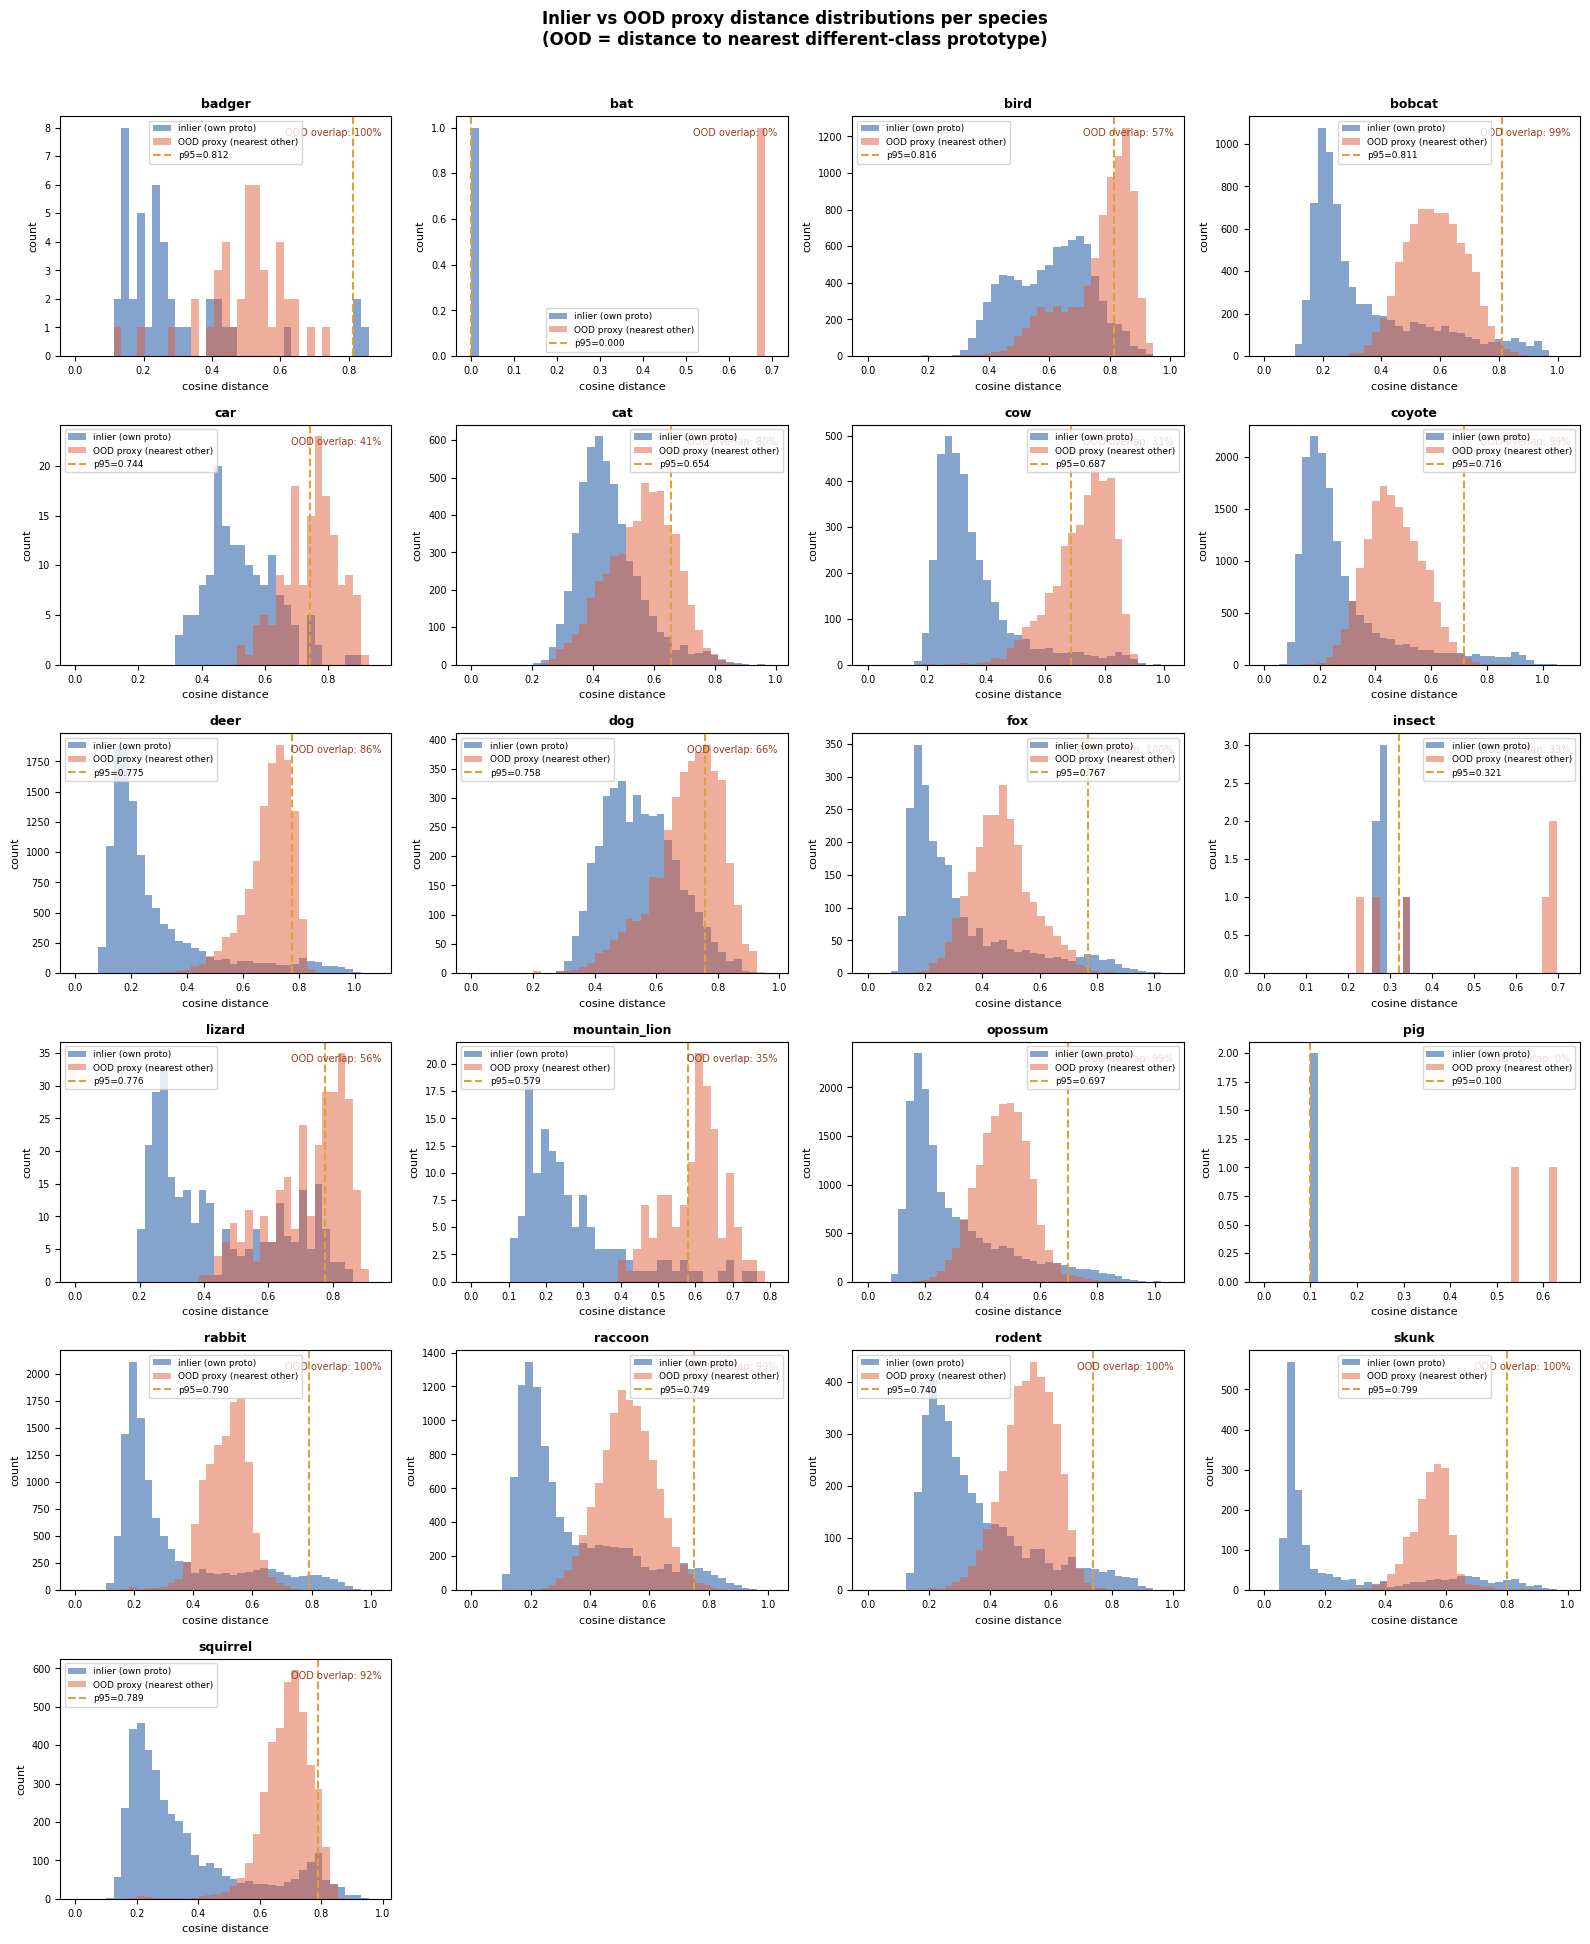

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── assumes prototypes dict already built from previous step ──────────────────
# prototypes = {species_name: unit_vector, ...}

unique_species = np.array(sorted(prototypes.keys()))
proto_matrix   = np.stack([prototypes[sp] for sp in unique_species])  # (C, D)

# ── inlier distances: each sample → its OWN prototype ─────────────────────────
inlier_dists = {}
for sp in unique_species:
    mask_sp   = species == sp
    embs      = embeddings[mask_sp]                    # (N, D)
    own_proto = prototypes[sp]                         # (D,)
    inlier_dists[sp] = (1.0 - embs @ own_proto).tolist()

# ── OOD proxy: each sample → nearest DIFFERENT-class prototype ────────────────
# sim_matrix shape: (N_samples, C_classes)
sim_matrix = embeddings @ proto_matrix.T               # cosine sim (both normalized)

ood_dists = {}
for sp in unique_species:
    mask_sp    = species == sp
    sims       = sim_matrix[mask_sp]                   # (N, C)
    sp_idx     = np.where(unique_species == sp)[0][0]
    # mask out own class column
    sims[:, sp_idx] = -np.inf
    nearest_other_sim  = sims.max(axis=1)              # best match among other classes
    ood_dists[sp] = (1.0 - nearest_other_sim).tolist()

# ── plot: one panel per species, inlier vs OOD overlaid ──────────────────────
ncols = 4
nrows = int(np.ceil(len(unique_species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.2))
axes = axes.flatten()

for i, sp in enumerate(unique_species):
    ax  = axes[i]
    ind = np.array(inlier_dists[sp])
    ood = np.array(ood_dists[sp])

    bins = np.linspace(0, max(ind.max(), ood.max()) * 1.05, 40)

    ax.hist(ind, bins=bins, color="#3266ad", alpha=0.6, label="inlier (own proto)")
    ax.hist(ood, bins=bins, color="#e05c3a", alpha=0.5, label="OOD proxy (nearest other)")

    # threshold candidate: 95th pct of inlier distances
    thresh = np.percentile(ind, 95)
    ax.axvline(thresh, color="#e0a03a", linewidth=1.5, linestyle="--",
               label=f"p95={thresh:.3f}")

    # overlap region annotation
    overlap = np.mean(ood < thresh)  # fraction of OOD samples below threshold
    ax.set_title(sp, fontsize=9, fontweight="bold")
    ax.set_xlabel("cosine distance", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5)
    ax.text(0.97, 0.95, f"OOD overlap: {overlap:.0%}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=7, color="#993C1D")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Inlier vs OOD proxy distance distributions per species\n"
             "(OOD = distance to nearest different-class prototype)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("inlier_vs_ood_per_species.png", dpi=150, bbox_inches="tight")
plt.show()

Fitted Platt models for 21 species


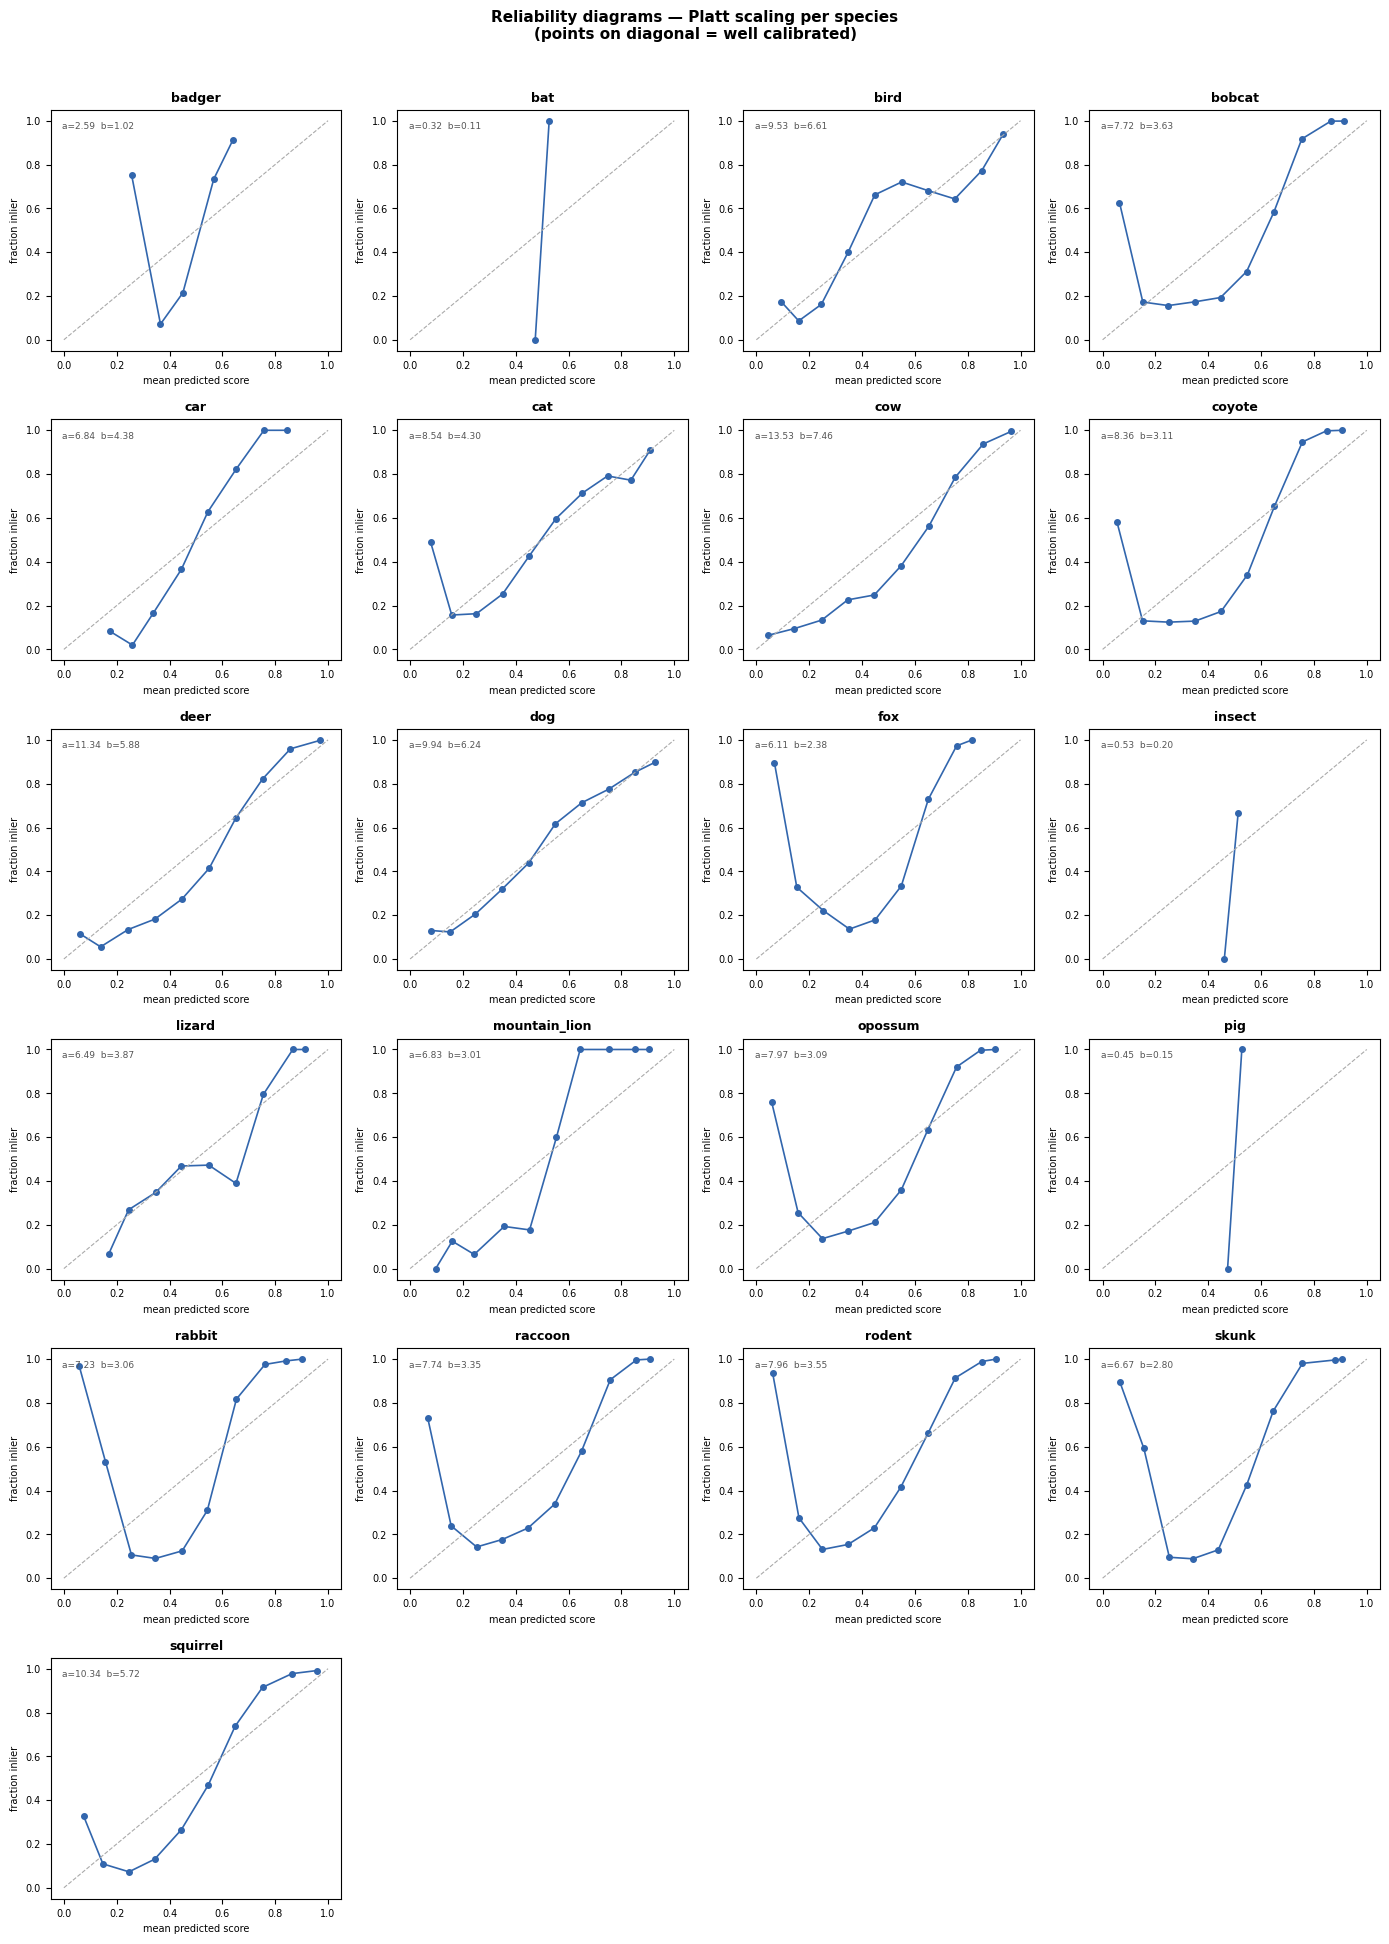


Species                    a       b     p95   n_inlier
-------------------------------------------------------
badger                 2.591   1.020   0.812         42
bat                    0.317   0.106   0.000          1
bird                   9.527   6.607   0.816       8494
bobcat                 7.716   3.631   0.811       7548
car                    6.844   4.376   0.744        152
cat                    8.540   4.304   0.654       5020
cow                   13.530   7.458   0.687       3618
coyote                 8.359   3.111   0.716      15631
deer                  11.339   5.884   0.775      11860
dog                    9.936   6.238   0.758       3951
fox                    6.108   2.375   0.767       2398
insect                 0.534   0.205   0.321          6
lizard                 6.490   3.868   0.776        287
mountain_lion          6.828   3.011   0.579        133
opossum                7.970   3.094   0.697      16099
pig                    0.452   0.153   0.100   

In [32]:
import numpy as np
from scipy.special import expit          # sigmoid: 1 / (1 + exp(-x))
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from collections import defaultdict

# ── 1. Build calibration dataset per species ──────────────────────────────────
# For each sample: distance to own prototype = inlier (y=1)
#                  distance to nearest other prototype = OOD proxy (y=0)

platt_models  = {}   # sp -> fitted LogisticRegression
platt_metrics = {}   # sp -> dict of diagnostics

for sp in unique_species:
    mask_sp = species == sp
    sp_idx  = np.where(unique_species == sp)[0][0]

    embs = embeddings[mask_sp]

    # inlier distances
    own_dist = 1.0 - (embs @ prototypes[sp])          # (N,)

    # OOD proxy distances
    sims = embs @ proto_matrix.T                       # (N, C)
    sims[:, sp_idx] = -np.inf
    ood_dist = 1.0 - sims.max(axis=1)                 # (N,)

    # build (distance, label) pairs
    # inlier = 1, OOD proxy = 0
    X = np.concatenate([own_dist, ood_dist]).reshape(-1, 1)
    y = np.concatenate([np.ones(len(own_dist)), np.zeros(len(ood_dist))])

    # ── 2. Fit Platt scaling (logistic regression on distances) ───────────────
    # Note: inlier = LOW distance = HIGH score
    # We fit on negative distance so the sigmoid maps naturally:
    # low distance → high logit → high probability
    lr = LogisticRegression(max_iter=1000)
    lr.fit(-X, y)                                      # negate: low dist = high input

    platt_models[sp]  = lr
    platt_metrics[sp] = {
        "a": float(lr.coef_[0][0]),
        "b": float(lr.intercept_[0]),
        "n_inlier": int(len(own_dist)),
        "n_ood":    int(len(ood_dist)),
        "p95_inlier": float(np.percentile(own_dist, 95)),
    }

print("Fitted Platt models for", len(platt_models), "species")

# ── 3. Scoring function ───────────────────────────────────────────────────────
def platt_score(embedding: np.ndarray, sp: str) -> float:
    """
    Returns confidence in [0, 1] that `embedding` belongs to `sp`.
    High score = likely inlier. Low score = likely OOD.
    embedding must already be L2-normalized.
    """
    dist = 1.0 - float(embedding @ prototypes[sp])
    return float(platt_models[sp].predict_proba([[-dist]])[0][1])

def score_all_classes(embedding: np.ndarray) -> dict:
    """Returns platt score for every class. Use for inspection."""
    return {sp: platt_score(embedding, sp) for sp in unique_species}

# ── 4. Calibration check: reliability diagrams ───────────────────────────────
ncols = 4
nrows = int(np.ceil(len(unique_species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

for i, sp in enumerate(unique_species):
    ax     = axes[i]
    mask_sp = species == sp
    sp_idx  = np.where(unique_species == sp)[0][0]
    embs    = embeddings[mask_sp]

    own_dist = 1.0 - (embs @ prototypes[sp])
    sims     = embs @ proto_matrix.T
    sims[:, sp_idx] = -np.inf
    ood_dist = 1.0 - sims.max(axis=1)

    X = np.concatenate([own_dist, ood_dist]).reshape(-1, 1)
    y = np.concatenate([np.ones(len(own_dist)), np.zeros(len(ood_dist))])

    scores = platt_models[sp].predict_proba(-X)[:, 1]

    # reliability diagram
    try:
        frac_pos, mean_pred = calibration_curve(y, scores, n_bins=10)
        ax.plot(mean_pred, frac_pos, "o-", color="#3266ad", markersize=4, linewidth=1.2)
    except ValueError:
        pass
    ax.plot([0, 1], [0, 1], "--", color="#aaaaaa", linewidth=0.8)

    m = platt_metrics[sp]
    ax.set_title(sp, fontsize=9, fontweight="bold")
    ax.set_xlabel("mean predicted score", fontsize=7)
    ax.set_ylabel("fraction inlier", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.text(0.04, 0.92, f"a={m['a']:.2f}  b={m['b']:.2f}",
            transform=ax.transAxes, fontsize=6.5, color="#555")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Reliability diagrams — Platt scaling per species\n(points on diagonal = well calibrated)",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("platt_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Species':<20} {'a':>7} {'b':>7} {'p95':>7} {'n_inlier':>10}")
print("-" * 55)
for sp, m in sorted(platt_metrics.items()):
    print(f"{sp:<20} {m['a']:>7.3f} {m['b']:>7.3f} {m['p95_inlier']:>7.3f} {m['n_inlier']:>10}")

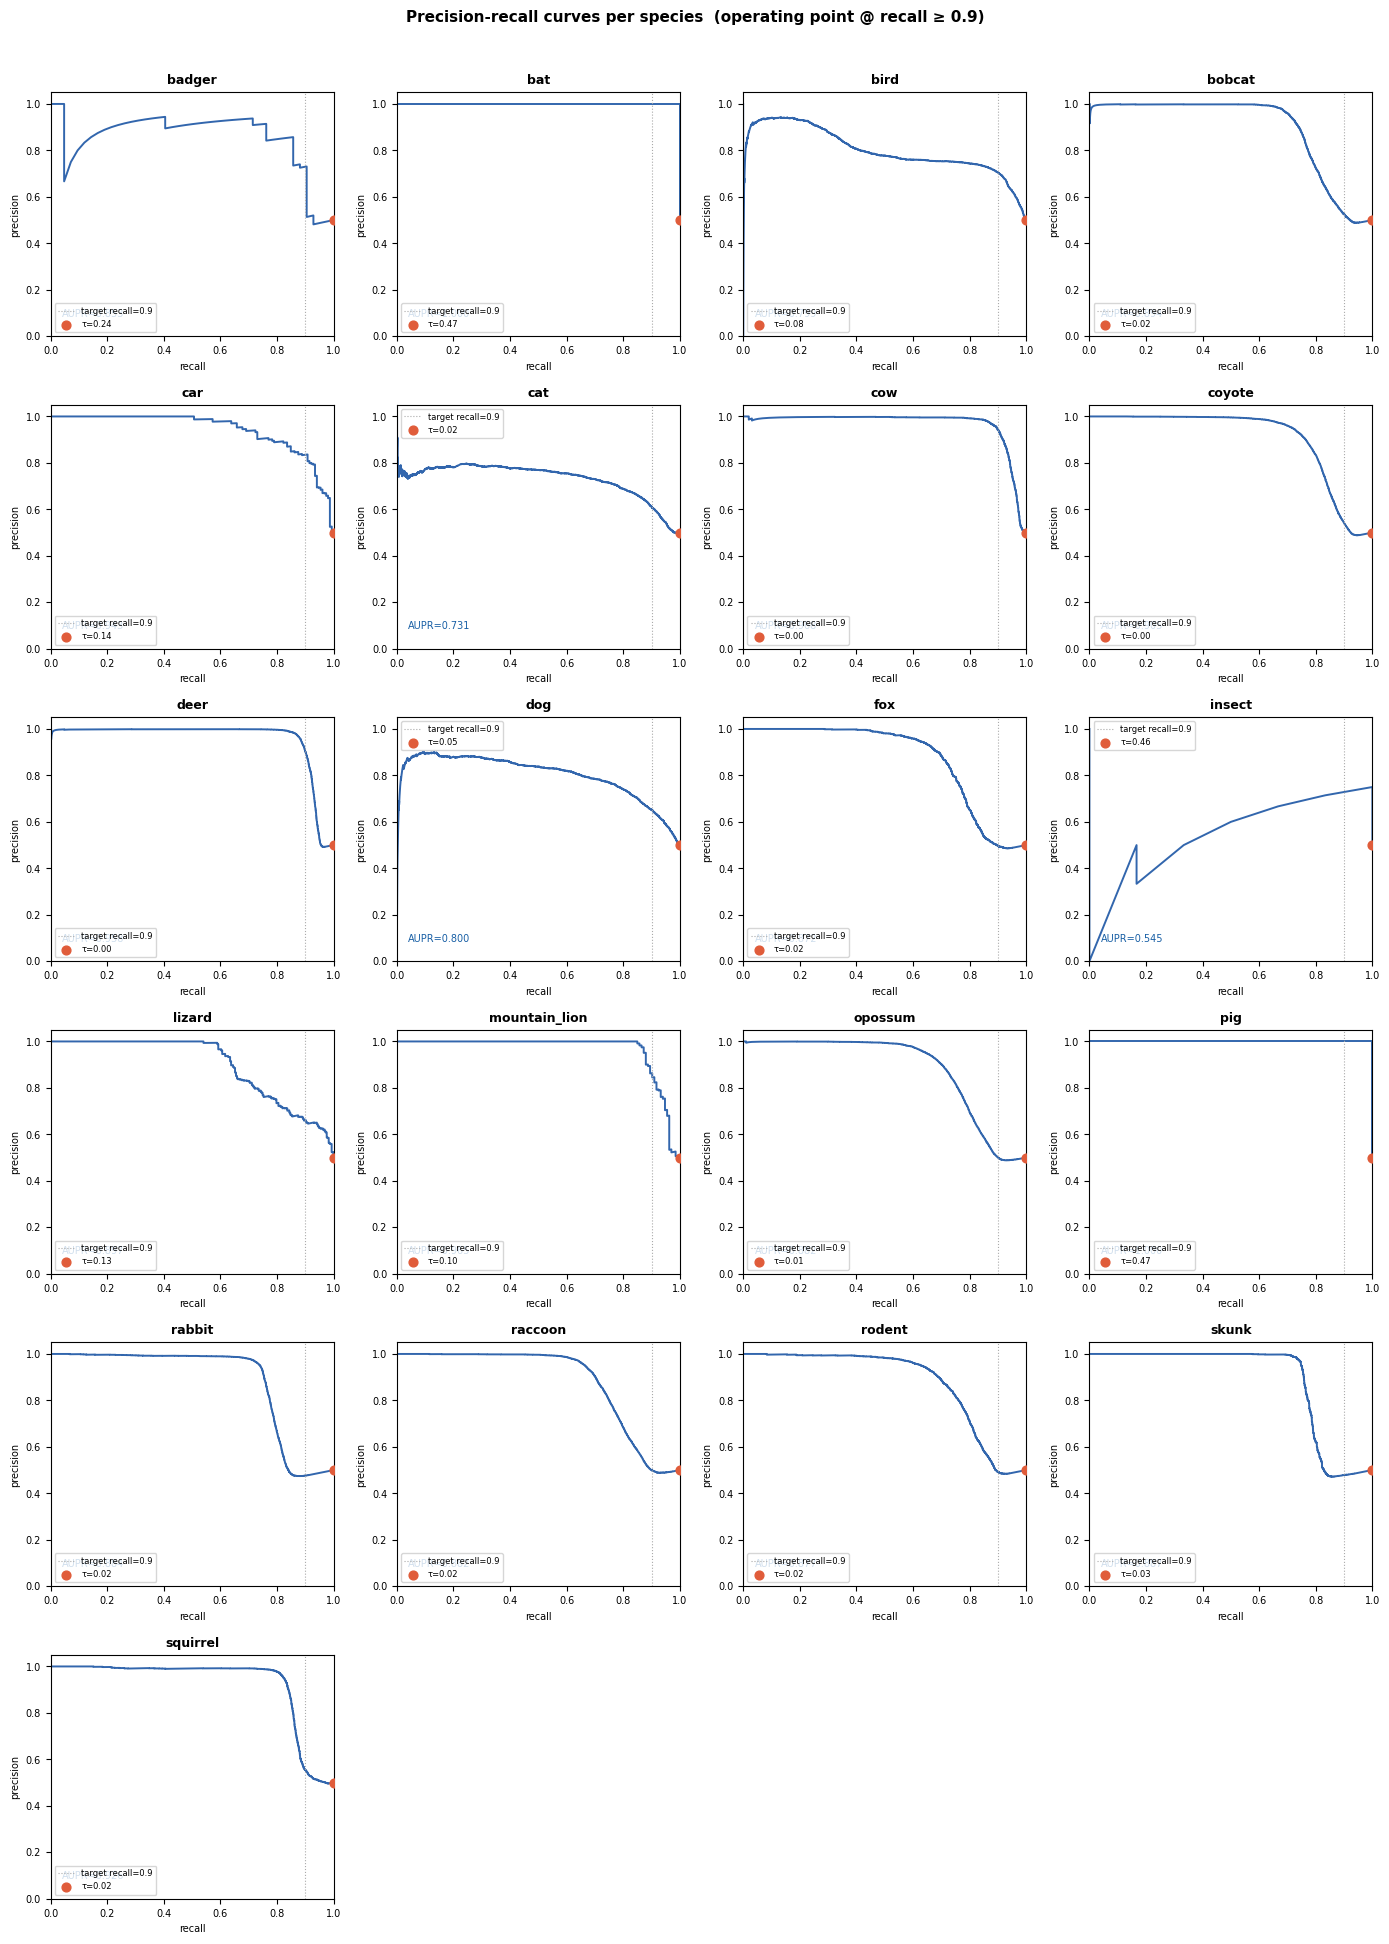


Species                AUPR   AUROC  threshold  precision  recall
-----------------------------------------------------------------
badger                0.853   0.853      0.240      0.500   1.000
bat                   1.000   1.000      0.474      0.500   1.000
bird                  0.799   0.823      0.082      0.500   1.000
bobcat                0.894   0.834      0.020      0.500   1.000
car                   0.943   0.932      0.139      0.500   1.000
cat                   0.731   0.769      0.023      0.500   1.000
cow                   0.968   0.955      0.004      0.500   1.000
coyote                0.905   0.852      0.004      0.500   1.000
deer                  0.958   0.930      0.003      0.500   1.000
dog                   0.800   0.824      0.047      0.500   1.000
fox                   0.872   0.803      0.023      0.500   1.000
insect                0.545   0.694      0.460      0.500   1.000  ← weak
lizard                0.897   0.872      0.129      0.500   1.000
m

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from collections import defaultdict

# ── 1. Build scored dataset per species ───────────────────────────────────────
# same (X, y) construction as before, now we compute PR + ROC curves

pr_data  = {}   # sp -> (precision, recall, thresholds, aupr)
roc_data = {}   # sp -> (fpr, tpr, thresholds, auroc)
op_points = {}  # sp -> chosen operating threshold on platt score

TARGET_RECALL = 0.90   # <── tune this: fraction of true inliers you want to keep

for sp in unique_species:
    mask_sp = species == sp
    sp_idx  = np.where(unique_species == sp)[0][0]
    embs    = embeddings[mask_sp]

    own_dist = 1.0 - (embs @ prototypes[sp])
    sims     = embs @ proto_matrix.T
    sims[:, sp_idx] = -np.inf
    ood_dist = 1.0 - sims.max(axis=1)

    X = np.concatenate([own_dist, ood_dist]).reshape(-1, 1)
    y = np.concatenate([np.ones(len(own_dist)), np.zeros(len(ood_dist))])

    scores = platt_models[sp].predict_proba(-X)[:, 1]

    # PR curve
    prec, rec, thresh_pr = precision_recall_curve(y, scores)
    aupr = auc(rec, prec)
    pr_data[sp] = (prec, rec, thresh_pr, aupr)

    # ROC curve
    fpr, tpr, thresh_roc = roc_curve(y, scores)
    auroc = auc(fpr, tpr)
    roc_data[sp] = (fpr, tpr, thresh_roc, auroc)

    # ── operating point: lowest threshold that still achieves TARGET_RECALL ───
    # precision_recall_curve returns arrays in decreasing threshold order
    # find first index where recall >= TARGET_RECALL
    valid = np.where(rec >= TARGET_RECALL)[0]
    if len(valid) > 0:
        idx = valid[0]                          # highest precision at target recall
        chosen_thresh  = float(thresh_pr[idx]) if idx < len(thresh_pr) else 0.5
        chosen_prec    = float(prec[idx])
        chosen_rec     = float(rec[idx])
    else:
        chosen_thresh, chosen_prec, chosen_rec = 0.5, 0.0, 0.0

    op_points[sp] = {
        "threshold":  chosen_thresh,
        "precision":  chosen_prec,
        "recall":     chosen_rec,
        "aupr":       aupr,
        "auroc":      auroc,
    }

# ── 2. Plot PR curves ─────────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(unique_species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

for i, sp in enumerate(unique_species):
    ax = axes[i]
    prec, rec, _, aupr = pr_data[sp]
    op = op_points[sp]

    ax.plot(rec, prec, color="#3266ad", linewidth=1.4)
    ax.axvline(TARGET_RECALL, color="#aaaaaa", linewidth=0.8,
               linestyle=":", label=f"target recall={TARGET_RECALL}")
    ax.scatter([op["recall"]], [op["precision"]], color="#e05c3a",
               s=40, zorder=5, label=f"τ={op['threshold']:.2f}")

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_title(sp, fontsize=9, fontweight="bold")
    ax.set_xlabel("recall", fontsize=7)
    ax.set_ylabel("precision", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
    ax.text(0.04, 0.08, f"AUPR={aupr:.3f}", transform=ax.transAxes,
            fontsize=7, color="#185FA5")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Precision-recall curves per species  (operating point @ recall ≥ {TARGET_RECALL})",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Species':<20} {'AUPR':>6} {'AUROC':>7} {'threshold':>10} "
      f"{'precision':>10} {'recall':>7}")
print("-" * 65)
for sp, op in sorted(op_points.items()):
    flag = "  ← weak" if op["aupr"] < 0.70 else ""
    print(f"{sp:<20} {op['aupr']:>6.3f} {op['auroc']:>7.3f} "
          f"{op['threshold']:>10.3f} {op['precision']:>10.3f} "
          f"{op['recall']:>7.3f}{flag}")

# ── 4. Classify a new embedding with rejection ────────────────────────────────
def classify(embedding: np.ndarray, verbose: bool = False) -> dict:
    """
    Given a single L2-normalized embedding, returns:
      - predicted_species: top scoring class
      - score:             platt confidence for that class
      - accepted:          True if score >= species threshold
      - all_scores:        dict of scores for every class
    """
    scores = {sp: platt_score(embedding, sp) for sp in unique_species}
    top_sp = max(scores, key=scores.get)
    top_sc = scores[top_sp]
    thresh = op_points[top_sp]["threshold"]
    accepted = top_sc >= thresh

    if verbose:
        print(f"Predicted : {top_sp}")
        print(f"Score     : {top_sc:.4f}  (threshold={thresh:.4f})")
        print(f"Decision  : {'ACCEPT' if accepted else 'REJECT → flag for review'}")

    return {
        "predicted_species": top_sp,
        "score":             top_sc,
        "accepted":          accepted,
        "threshold":         thresh,
        "all_scores":        scores,
    }

badger 1
badger 2
badger 3
bird 1
bird 2
bird 3
bobcat 1
bobcat 2
bobcat 3
car 1
car 2
car 3
cat 1
cat 2
cat 3
cow 1
cow 2
cow 3
coyote 1
coyote 2
coyote 3
deer 1
deer 2
deer 3
dog 1
dog 2
dog 3
fox 1
fox 2
fox 3
insect 1
insect 2
insect 3
lizard 1
lizard 2
lizard 3
mountain_lion 1
mountain_lion 2
mountain_lion 3
opossum 1
opossum 2
opossum 3
pig 1
rabbit 1
rabbit 2
rabbit 3
raccoon 1
raccoon 2
raccoon 3
rodent 1
rodent 2
rodent 3
skunk 1
skunk 2
skunk 3
squirrel 1
squirrel 2
squirrel 3


NameError: name 'p' is not defined

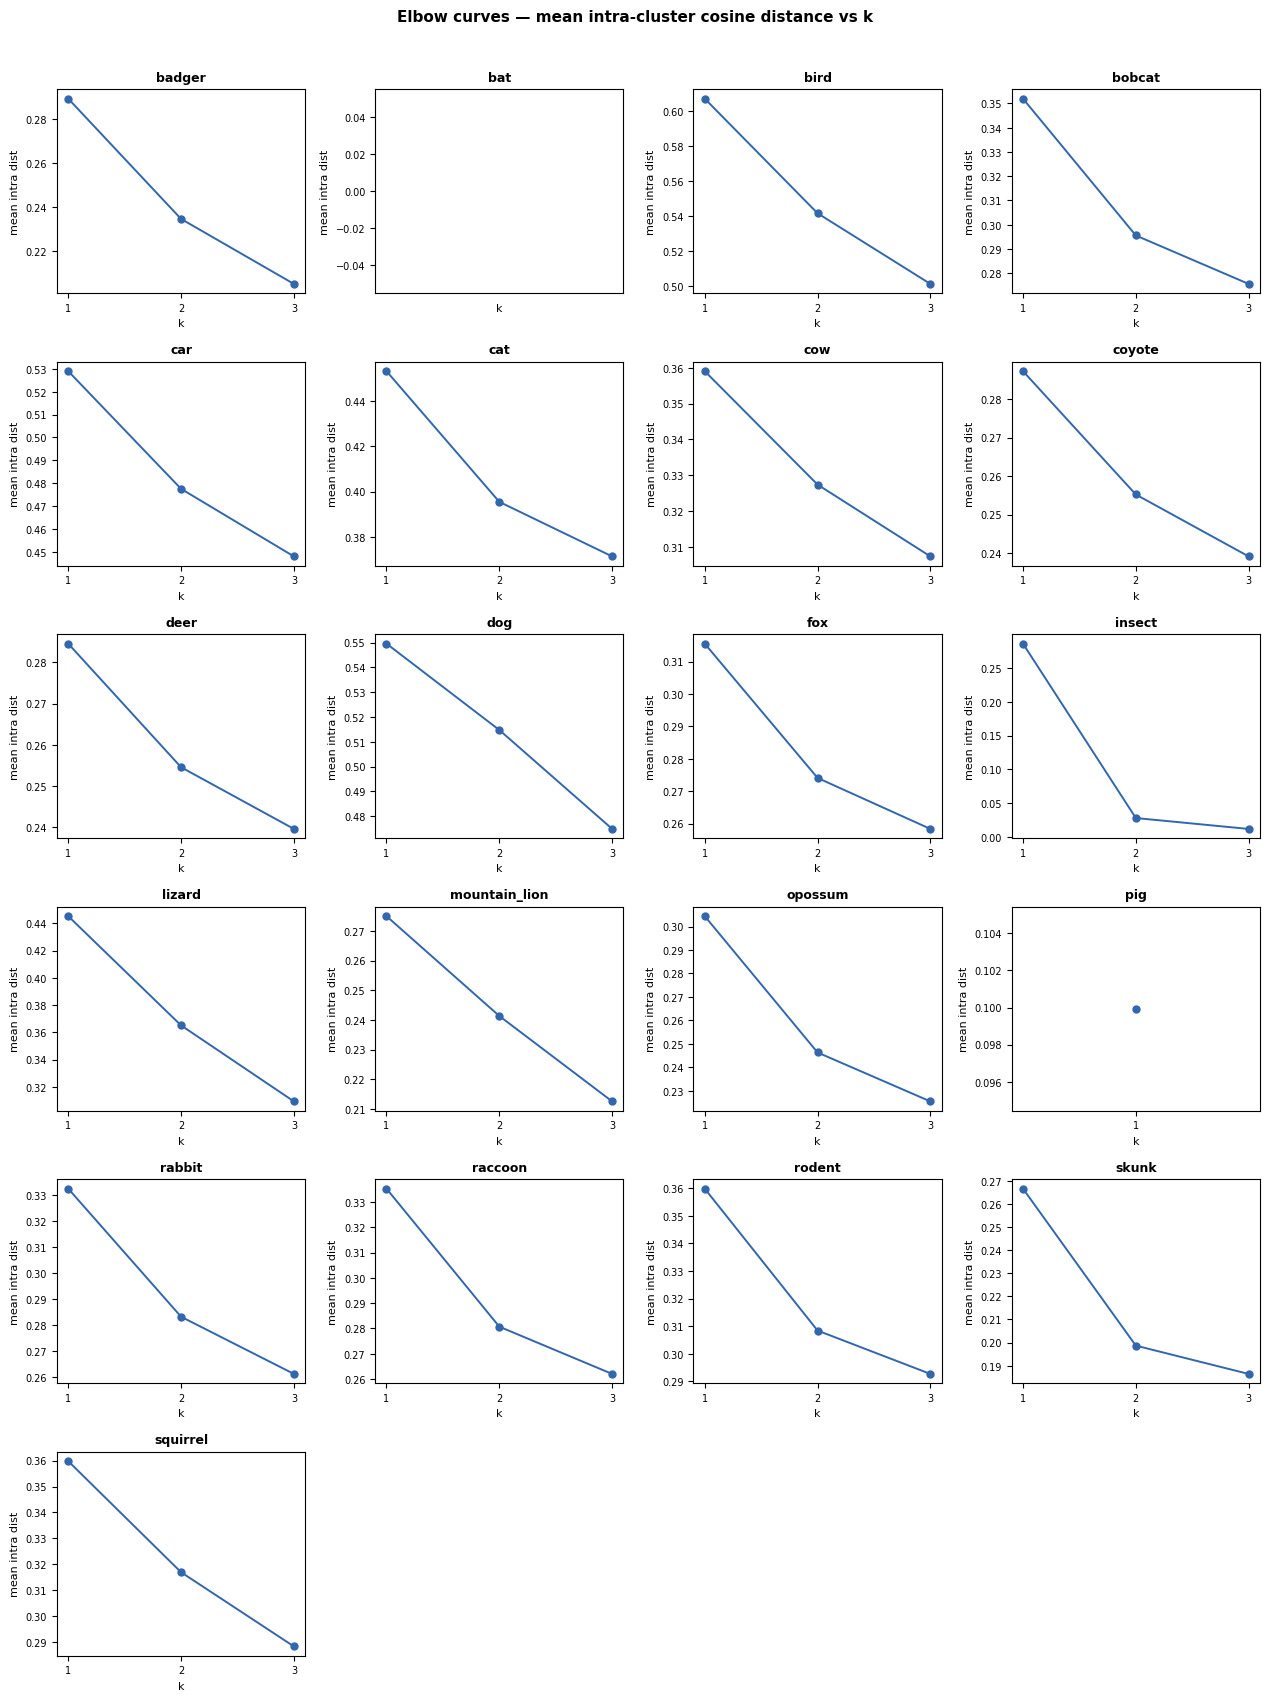

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# species where we already saw bimodal/wide distributions
# run elbow for all, but pay special attention to these
CANDIDATE_SPECIES = ["opossum", "lizard", "bird", "rabbit", "rodent",
                     "squirrel", "skunk", "cat", "dog"]

MAX_K   = 3
elbow   = {}   # sp -> list of mean intra-cluster cosine distances for k=1..MAX_K

for sp in unique_species:
    mask_sp = species == sp
    embs    = embeddings[mask_sp]
    n       = len(embs)
    scores  = []
    for k in range(1, min(MAX_K + 1, n)):
        print(sp, k)
        km   = KMeans(n_clusters=k, n_init=10, random_state=42)
        lbls = km.fit_predict(embs)
        # mean cosine distance to assigned cluster centre (re-normalized)
        centres = normalize(km.cluster_centers_, norm="l2")
        dist    = 1.0 - np.sum(embs * centres[lbls], axis=1)
        scores.append(float(dist.mean()))
    elbow[sp] = scores

# ── plot ──────────────────────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(unique_species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.8))
axes = axes.flatten()

for i, sp in enumerate(unique_species):
    ax  = axes[i]
    ks  = range(1, len(elbow[sp]) + 1)
    ax.plot(list(ks), elbow[sp], "o-", color="#3266ad", linewidth=1.4, markersize=5)
    ax.set_title(sp, fontsize=9, fontweight="bold")
    ax.set_xlabel("k", fontsize=8)
    ax.set_ylabel("mean intra dist", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_xticks(list(ks))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Elbow curves — mean intra-cluster cosine distance vs k",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("elbow_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from collections import defaultdict

# ── set k per species based on elbow inspection ───────────────────────────────
# defaults to 1 for all; override after seeing elbow plots
SPECIES_K = {sp: 1 for sp in unique_species}
# example overrides — fill in after elbow inspection:
SPECIES_K["insect"] = 2
# SPECIES_K["lizard"]  = 2
# SPECIES_K["bird"]    = 3

# ── build gallery ─────────────────────────────────────────────────────────────
# gallery structure:
#   gallery[sp] = list of dicts, one per sub-prototype
#   each dict: { "proto": unit_vec, "threshold": float, "label": str }

gallery = defaultdict(list)

for sp in unique_species:
    mask_sp = species == sp
    embs    = embeddings[mask_sp]
    k       = SPECIES_K[sp]

    if k == 1:
        proto = normalize(embs.mean(axis=0, keepdims=True), norm="l2")[0]
        dists = 1.0 - (embs @ proto)
        gallery[sp].append({
            "proto":     proto,
            "threshold": float(np.percentile(dists, 95)),
            "label":     sp,
            "n":         len(embs),
        })

    else:
        km   = KMeans(n_clusters=k, n_init=10, random_state=42)
        lbls = km.fit_predict(embs)
        for c in range(k):
            mask_c  = lbls == c
            sub_embs = embs[mask_c]
            if len(sub_embs) < 3:          # skip degenerate clusters
                continue
            proto = normalize(sub_embs.mean(axis=0, keepdims=True), norm="l2")[0]
            dists = 1.0 - (sub_embs @ proto)
            gallery[sp].append({
                "proto":     proto,
                "threshold": float(np.percentile(dists, 95)),
                "label":     f"{sp}_c{c}",
                "n":         int(mask_c.sum()),
            })

# ── print gallery summary ─────────────────────────────────────────────────────
print(f"\n{'Species':<20} {'k':>3}  sub-prototypes")
print("-" * 60)
for sp in sorted(gallery.keys()):
    entries = gallery[sp]
    print(f"{sp:<20} {len(entries):>3}")
    for e in entries:
        print(f"    {e['label']:<28} n={e['n']:>4}  p95={e['threshold']:.4f}")


Species                k  sub-prototypes
------------------------------------------------------------
badger                 1
    badger                       n=  42  p95=0.8119
bat                    1
    bat                          n=   1  p95=0.0000
bird                   1
    bird                         n=8494  p95=0.8156
bobcat                 1
    bobcat                       n=7548  p95=0.8106
car                    1
    car                          n= 152  p95=0.7437
cat                    1
    cat                          n=5020  p95=0.6544
cow                    1
    cow                          n=3618  p95=0.6871
coyote                 1
    coyote                       n=15631  p95=0.7156
deer                   1
    deer                         n=11860  p95=0.7751
dog                    1
    dog                          n=3951  p95=0.7583
fox                    1
    fox                          n=2398  p95=0.7668
insect                 2
    insect_c0          

In [39]:
def classify(embedding: np.ndarray, verbose: bool = False) -> dict:
    """
    Scores embedding against every sub-prototype in the gallery.
    Accepts if cosine distance to nearest sub-prototype is below
    that sub-prototype's p95 inlier threshold.
    """
    best_sp      = None
    best_dist    = np.inf
    best_entry   = None

    for sp, entries in gallery.items():
        for entry in entries:
            dist = 1.0 - float(embedding @ entry["proto"])
            if dist < best_dist:
                best_dist  = dist
                best_sp    = sp
                best_entry = entry

    accepted = best_dist <= best_entry["threshold"]

    if verbose:
        print(f"Predicted : {best_sp}")
        print(f"Distance  : {best_dist:.4f}  (p95 threshold={best_entry['threshold']:.4f})")
        print(f"Decision  : {'ACCEPT' if accepted else 'REJECT → flag for review'}")

    return {
        "predicted_species": best_sp,
        "distance":          best_dist,
        "threshold":         best_entry["threshold"],
        "accepted":          accepted,
        "sub_prototype":     best_entry["label"],
    }